# 차종 이미지 다중분류 모델 학습 (SUV / 승용차 / 경차)

- 데이터: `차종분류데이터/<카테고리>/원천데이터/...` (P00 필터 + 차종→카테고리 라벨 완료)
- 분류 클래스: **SUV, 승용차, 경차** (트럭 제외)
- 모델: torchvision ResNet18 (ImageNet 사전학습) → 마지막 층만 3-class로 교체
- 불균형 처리: 클래스 가중치를 CrossEntropyLoss에 적용
- **저장**: `best.pt`(검증 정확도 최고 시점) + `last.pt`(매 에폭, 중단 후 재개용)
- **조기 종료**: 검증 정확도가 일정 에폭 이상 개선 없으면 자동 중단
- **PART 4**: 학습 없이 `best.pt`만 받아 다른 사람도 바로 추론할 수 있는 파트 분리

## 0. 환경 확인 (GPU)

In [1]:
import os, sys, json, random
from pathlib import Path
from collections import Counter

import cv2
import torch
from tqdm import tqdm

print("Python:", sys.version)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("⚠️ GPU를 찾지 못했습니다. CPU로 진행하면 매우 느립니다. 드라이버/torch 설치를 확인하세요.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA version: 12.8
사용 디바이스: cuda


## 1. 추가 라이브러리 확인 (torchvision)

In [2]:
try:
    import torchvision
    print("torchvision:", torchvision.__version__)
except ImportError:
    print("torchvision이 없어 설치를 시도합니다...")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "torchvision"], check=True)
    import torchvision
    print("설치 완료 · torchvision:", torchvision.__version__)

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn as nn
import torch.optim as optim

torchvision: 0.27.0.dev20260407+cu128


---
# PART 0 · 경로 & 공통 설정

In [3]:
# ==== 데이터 경로 ====
DATA_ROOT = Path(r"C:\Users\Win11Pro\Desktop\차종분류데이터")
# ====================

CLASSES = ["SUV", "승용차", "경차"]     # 학습에 쓸 클래스 (트럭 제외)
IMG_EXTS = {".jpg", ".jpeg", ".png"}

VAL_RATIO = 0.15
SEED = 42
IMG_SIZE = 224

random.seed(SEED)
torch.manual_seed(SEED)

# --- 체크포인트 경로 (다른 사람은 이 폴더의 best.pt만 받으면 됨) ---
CKPT_DIR = Path("./checkpoints")
CKPT_DIR.mkdir(exist_ok=True)
BEST_CKPT   = CKPT_DIR / "best.pt"     # 검증 정확도 최고 시점 (배포·추론용)
LAST_CKPT   = CKPT_DIR / "last.pt"     # 매 에폭 (중단 후 재개용)
HISTORY_JSON = CKPT_DIR / "history.json"

class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

## 2. 이미지 목록 수집 + train/val 분할

클래스별로 이미지를 모은 뒤, 각 클래스 내에서 `VAL_RATIO`만큼 검증용으로 떼어냅니다(클래스 비율 유지).

In [4]:
def collect_images(cat: str):
    root = DATA_ROOT / cat / "원천데이터"
    if not root.exists():
        raise FileNotFoundError(f"경로 없음: {root}")
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS]

train_samples, val_samples = [], []

for cat in CLASSES:
    paths = collect_images(cat)
    random.shuffle(paths)
    n_val = int(len(paths) * VAL_RATIO)
    val_paths, train_paths = paths[:n_val], paths[n_val:]
    label = class_to_idx[cat]
    train_samples += [(p, label) for p in train_paths]
    val_samples += [(p, label) for p in val_paths]
    print(f"{cat:<6} 전체 {len(paths):>7,} · train {len(train_paths):>7,} · val {len(val_paths):>6,}")

random.shuffle(train_samples)
random.shuffle(val_samples)
print(f"\n총 train {len(train_samples):,} · val {len(val_samples):,}")

SUV    전체  40,048 · train  34,041 · val  6,007
승용차    전체  39,620 · train  33,677 · val  5,943
경차     전체   7,742 · train   6,581 · val  1,161

총 train 74,299 · val 13,111


## 3. 클래스 가중치 계산 (불균형 보정)

In [5]:
train_labels = [label for _, label in train_samples]
counts = Counter(train_labels)
total = sum(counts.values())

class_weights = torch.tensor(
    [total / (len(CLASSES) * counts[i]) for i in range(len(CLASSES))],
    dtype=torch.float32,
).to(device)

print("클래스별 train 개수:", {idx_to_class[i]: counts[i] for i in range(len(CLASSES))})
print("클래스 가중치:", {idx_to_class[i]: round(w.item(), 3) for i, w in enumerate(class_weights)})

클래스별 train 개수: {'SUV': 34041, '승용차': 33677, '경차': 6581}
클래스 가중치: {'SUV': 0.728, '승용차': 0.735, '경차': 3.763}


## 4. Dataset / 모델 / 체크포인트 함수 정의

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class VehicleDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

def build_model(pretrained=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, len(CLASSES))
    return m

def save_checkpoint(path, model, optimizer=None, scheduler=None,
                     epoch=None, best_val=None, history=None, no_improve=None):
    """다른 사람이 재현할 수 있도록 모델뿐 아니라 클래스 목록·전처리 설정도 함께 저장."""
    ck = {
        "model": model.state_dict(),
        "classes": CLASSES,
        "img_size": IMG_SIZE,
    }
    if optimizer  is not None: ck["optimizer"]  = optimizer.state_dict()
    if scheduler  is not None: ck["scheduler"]  = scheduler.state_dict()
    if epoch      is not None: ck["epoch"]      = epoch
    if best_val   is not None: ck["best_val"]   = best_val
    if history    is not None: ck["history"]    = history
    if no_improve is not None: ck["no_improve"] = no_improve
    torch.save(ck, path)

print("정의 완료: VehicleDataset · build_model · save_checkpoint")

정의 완료: VehicleDataset · build_model · save_checkpoint


---
# PART 1 · 학습 설정 ⚙️ (하이퍼파라미터는 여기서만 바꾸고, 이 파트부터 아래로 재실행)

> ⚠️ **`NUM_WORKERS`는 기본 0을 권장합니다.** Windows + Jupyter 환경에서는 워커 프로세스가
> `spawn` 방식으로 실행 중인 노트북을 다시 import하려다 걸려서, 에러 없이 진행률 0%에서
> 멈추는 경우가 많습니다(`.py` 스크립트로 돌릴 때만 4 이상으로 올려도 안전합니다).

In [7]:
# ── 하이퍼파라미터 ──────────────────────────────────────────
BATCH_SIZE  = 32        # OOM 시 16으로
EPOCHS      = 50        # 넉넉히 잡아도 조기종료가 알아서 멈춤
LR          = 1e-4
NUM_WORKERS = 0         # Windows+Jupyter 안전값. .py 스크립트로 돌릴 땐 4+ 권장

RESUME = True          # last.pt에서 이어서 학습하려면 True

EARLY_STOP_PATIENCE = 7   # 검증 정확도가 이 에폭 수만큼 개선 없으면 조기종료 (<0이면 끔)
MIN_DELTA = 0.001         # 개선으로 인정할 최소 정확도 증가
# ────────────────────────────────────────────────────────────

train_loader = DataLoader(VehicleDataset(train_samples, train_transform),
                           batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(VehicleDataset(val_samples, val_transform),
                         batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"train 배치 수: {len(train_loader)} · val 배치 수: {len(val_loader)}")
print(f"batch {BATCH_SIZE} | epochs {EPOCHS} | lr {LR} | resume {RESUME}")

train 배치 수: 2322 · val 배치 수: 410
batch 32 | epochs 50 | lr 0.0001 | resume True


## 5. 모델·옵티마이저·스케줄러 준비 (RESUME이면 last.pt에서 복원)

In [8]:
model = build_model(pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

if RESUME and LAST_CKPT.exists():
    ck = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ck["model"])
    optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"])
    start_epoch = ck["epoch"] + 1
    best_val = ck["best_val"]
    history = ck["history"]
    epochs_no_improve = ck.get("no_improve", 0)
    print(f"🔄 재개: epoch {start_epoch}부터 · best_val {best_val:.3f} · 개선정체 {epochs_no_improve}")
else:
    start_epoch, best_val, epochs_no_improve = 1, 0.0, 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    print("🆕 새로 학습 시작")

n_params = sum(p.numel() for p in model.parameters())
print(f"모델: ResNet18 · 파라미터 {n_params:,}개 · 출력 클래스 {len(CLASSES)}개")

🔄 재개: epoch 5부터 · best_val 0.987 · 개선정체 0
모델: ResNet18 · 파라미터 11,178,051개 · 출력 클래스 3개


---
# PART 2 · 학습 (best 즉시 저장 · 조기 종료 · 중단 재개)

- `best.pt`: 검증 정확도가 가장 높을 때 저장 → PART 4가 이걸 로드해서 배포/추론
- `last.pt`: 매 에폭 저장(조기종료 카운터 포함) → `RESUME=True`로 이어서 학습
- **조기 종료**: 검증 정확도가 `EARLY_STOP_PATIENCE` 에폭 연속 `MIN_DELTA` 이상 개선되지 않으면 자동 중단
- 중간에 정지(Kernel Interrupt)해도 `KeyboardInterrupt`를 잡아 last.pt를 저장하고 안전하게 끝냅니다

In [9]:
def run_epoch(loader, train_mode: bool):
    model.train() if train_mode else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for imgs, labels in tqdm(loader, desc="train" if train_mode else "val", leave=False):
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            if train_mode:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train_mode:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_n += imgs.size(0)
    return total_loss / total_n, total_correct / total_n

try:
    for epoch in range(start_epoch, EPOCHS + 1):
        train_loss, train_acc = run_epoch(train_loader, train_mode=True)
        val_loss, val_acc = run_epoch(val_loader, train_mode=False)
        scheduler.step(val_acc)

        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

        # 개선 판정 (MIN_DELTA 이상 증가해야 개선으로 인정)
        if val_acc > best_val + MIN_DELTA:
            best_val = val_acc
            epochs_no_improve = 0
            save_checkpoint(BEST_CKPT, model, best_val=best_val)
            flag = f"✔ best 저장 (val acc {best_val:.3f})"
        else:
            epochs_no_improve += 1
            flag = f"개선 없음 {epochs_no_improve}/{EARLY_STOP_PATIENCE}"

        print(f"[{epoch:02d}/{EPOCHS}] train loss {train_loss:.4f} acc {train_acc:.3f} · "
              f"val loss {val_loss:.4f} acc {val_acc:.3f} · lr {optimizer.param_groups[0]['lr']:.1e} · {flag}")

        # 매 에폭 last 저장 (조기종료 카운터 포함, 재개용)
        save_checkpoint(LAST_CKPT, model, optimizer, scheduler,
                         epoch=epoch, best_val=best_val, history=history,
                         no_improve=epochs_no_improve)
        json.dump(history, open(HISTORY_JSON, "w"))

        # 조기 종료 (EARLY_STOP_PATIENCE < 0 이면 비활성)
        if EARLY_STOP_PATIENCE >= 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ 조기 종료: val acc가 {EARLY_STOP_PATIENCE}에폭 연속 개선 없음 (best {best_val:.3f})")
            break

except KeyboardInterrupt:
    print("\n⚠️ 학습이 중단되었습니다. 마지막 상태를 last.pt에 저장합니다.")
    save_checkpoint(LAST_CKPT, model, optimizer, scheduler,
                     epoch=epoch, best_val=best_val, history=history,
                     no_improve=epochs_no_improve)

print(f"\n학습 종료 · 최고 val acc: {best_val:.3f}")
print(f"최종모델(best): {BEST_CKPT}")
print(f"재개용(last):   {LAST_CKPT}")

[05/50] train loss 0.0223 acc 0.991 · val loss 0.0355 acc 0.986 · lr 1.0e-04 · 개선 없음 1/7


[06/50] train loss 0.0209 acc 0.992 · val loss 0.0303 acc 0.987 · lr 1.0e-04 · 개선 없음 2/7


[07/50] train loss 0.0147 acc 0.994 · val loss 0.0558 acc 0.984 · lr 1.0e-04 · 개선 없음 3/7


[08/50] train loss 0.0160 acc 0.994 · val loss 0.0267 acc 0.989 · lr 1.0e-04 · ✔ best 저장 (val acc 0.989)


[09/50] train loss 0.0155 acc 0.994 · val loss 0.0324 acc 0.987 · lr 1.0e-04 · 개선 없음 1/7


...

[19/50] train loss 0.0023 acc 0.999 · val loss 0.0168 acc 0.995 · lr 5.0e-05 · 개선 없음 3/7


[20/50] train loss 0.0029 acc 0.999 · val loss 0.0217 acc 0.994 · lr 5.0e-05 · 개선 없음 4/7


[21/50] train loss 0.0019 acc 0.999 · val loss 0.0212 acc 0.993 · lr 5.0e-05 · 개선 없음 5/7


[22/50] train loss 0.0022 acc 0.999 · val loss 0.0251 acc 0.995 · lr 5.0e-05 · 개선 없음 6/7


[23/50] train loss 0.0019 acc 0.999 · val loss 0.0197 acc 0.995 · lr 2.5e-05 · 개선 없음 7/7

⏹ 조기 종료: val acc가 7에폭 연속 개선 없음 (best 0.995)

학습 종료 · 최고 val acc: 0.995
최종모델(best): checkpoints\best.pt
재개용(last):   checkpoints\last.pt


---
# PART 3 · 학습 곡선 확인

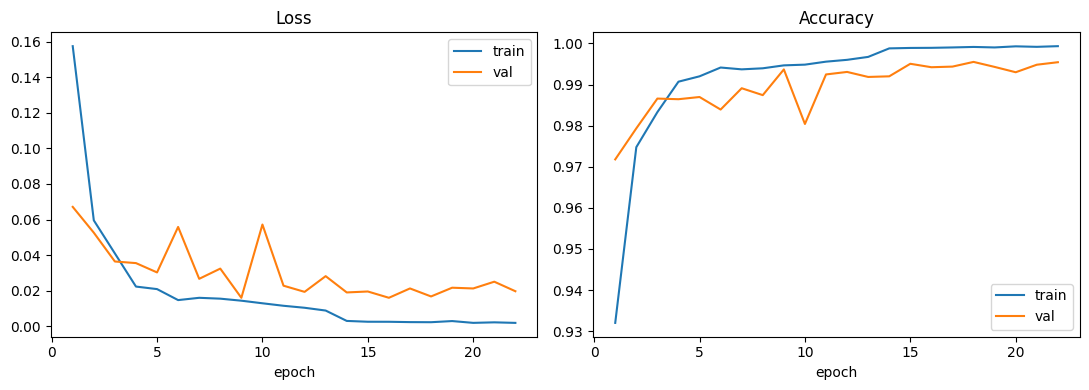

In [10]:
import matplotlib.pyplot as plt

hist = json.load(open(HISTORY_JSON, encoding="utf-8")) if HISTORY_JSON.exists() else history
epochs_range = range(1, len(hist["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_range, hist["train_loss"], label="train")
axes[0].plot(epochs_range, hist["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(epochs_range, hist["train_acc"], label="train")
axes[1].plot(epochs_range, hist["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout(); plt.show()

---
# PART 4 · 평가·추론 *(학습 없이 best.pt만 로드 — 다른 사람도 이 파트만 실행 가능)*

> 다른 사람은 `checkpoints/best.pt` 파일 하나만 받아서 이 파트(PART 4)만 실행하면 됩니다.
> 위쪽 PART 0의 라이브러리 import 셀(0~1번)만 먼저 실행한 뒤 여기로 바로 넘어오면 됩니다.

In [11]:
assert BEST_CKPT.exists(), "best.pt가 없습니다 — PART 2를 먼저 실행하거나, 체크포인트를 받아 checkpoints/ 폴더에 두세요."

ck = torch.load(BEST_CKPT, map_location=device)
EVAL_CLASSES = ck["classes"]
EVAL_IMG_SIZE = ck["img_size"]

eval_model = build_model(pretrained=False)
eval_model.load_state_dict(ck["model"])
eval_model = eval_model.to(device)
eval_model.eval()

eval_transform = transforms.Compose([
    transforms.Resize((EVAL_IMG_SIZE, EVAL_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print(f"✅ best.pt 로드 완료 · 클래스 {EVAL_CLASSES} · val acc {ck.get('best_val', '?')}")

✅ best.pt 로드 완료 · 클래스 ['SUV', '승용차', '경차'] · val acc 0.9950423308672107


## 4-1. 혼동행렬로 클래스별 성능 확인

In [12]:
n = len(EVAL_CLASSES)
confusion = torch.zeros(n, n, dtype=torch.int64)

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="평가"):
        imgs = imgs.to(device)
        preds = eval_model(imgs).argmax(1).cpu()
        for t, p in zip(labels, preds):
            confusion[t, p] += 1

print("혼동행렬 (행=실제, 열=예측)")
print(f"{'':<8}" + "".join(f"{c:>10}" for c in EVAL_CLASSES))
for i, c in enumerate(EVAL_CLASSES):
    print(f"{c:<8}" + "".join(f"{confusion[i,j].item():>10}" for j in range(n)))

print("\n클래스별 정확도(재현율):")
for i, c in enumerate(EVAL_CLASSES):
    row_total = confusion[i].sum().item()
    acc = confusion[i, i].item() / row_total if row_total else 0
    print(f"  {c}: {acc:.3f} ({confusion[i,i].item()}/{row_total})")

평가: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 410/410 [07:43<00:00,  1.13s/it]

혼동행렬 (행=실제, 열=예측)
               SUV       승용차        경차
SUV           5965        35         7
승용차             19      5924         0
경차               3         1      1157

클래스별 정확도(재현율):
  SUV: 0.993 (5965/6007)
  승용차: 0.997 (5924/5943)
  경차: 0.997 (1157/1161)


## 4-2. 단일 이미지 추론

`TEST_IMAGE_PATH`를 원하는 이미지 경로로 바꾸면 됩니다.

In [13]:
TEST_IMAGE_PATH = val_samples[0][0]   # 예시: 검증셋 첫 번째 이미지

def predict(image_path: Path):
    img = Image.open(image_path).convert("RGB")
    x = eval_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(eval_model(x), dim=1)[0].cpu()
    return sorted(zip(EVAL_CLASSES, probs.tolist()), key=lambda x: -x[1])

result = predict(TEST_IMAGE_PATH)
print(f"이미지: {TEST_IMAGE_PATH}")
for cls, prob in result:
    print(f"  {cls}: {prob*100:.1f}%")

이미지: C:\Users\Win11Pro\Desktop\차종분류데이터\승용차\원천데이터\TS4\RS_르노삼성\036_SM6\2018_검정_트림B\C_210911_RS_036_18_BK_B_T_02_010.jpg
  승용차: 100.0%
  SUV: 0.0%
  경차: 0.0%
